# Sales Prediction Using Python

## Objective
The objective of this project is to predict future sales using advertising spend data across TV, Radio, and Newspaper channels using machine learning in Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In [3]:
df = pd.read_csv('Advertising.csv')

### Checking Dataset Information

In [4]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400

### Cleaning the Dataset

In [5]:
df = df.drop(columns=['Unnamed: 0'])
print(df.head())
print("Dataset shape:", df.shape)

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
Dataset shape: (200, 4)


### Sales Distribution

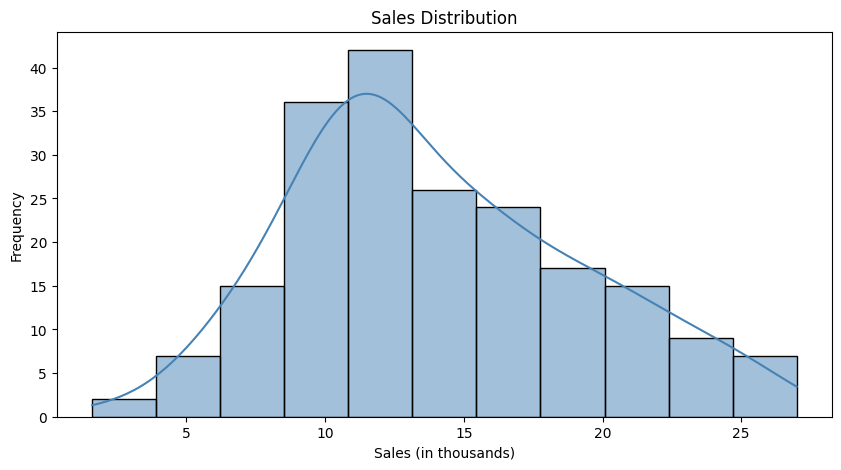

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, color='steelblue')
plt.title("Sales Distribution")
plt.xlabel("Sales (in thousands)")
plt.ylabel("Frequency")
plt.show()

### Advertising Spend vs Sales

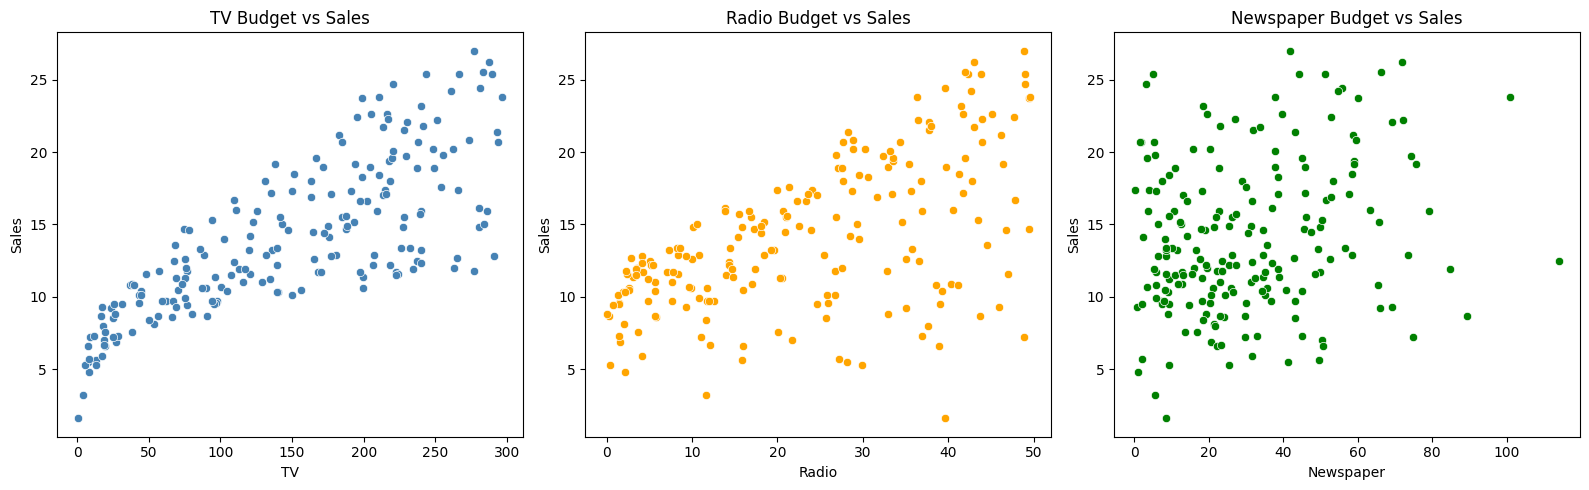

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(axes, ['TV', 'Radio', 'Newspaper'], ['steelblue', 'orange', 'green']):
    sns.scatterplot(x=col, y='Sales', data=df, ax=ax, color=color)
    ax.set_title(f"{col} Budget vs Sales")
plt.tight_layout()
plt.show()

### Correlation Heatmap

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### Preparing Features and Target Variable

In [10]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 3)
Target shape: (200,)


### Splitting the Dataset into Train and Test Sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (160, 3)
Testing set size: (40, 3)


### Training — Linear Regression and Random Forest Models

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Linear Regression Trained Successfully")

Linear Regression Trained Successfully


In [13]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print("Random Forest Trained Successfully")

Random Forest Trained Successfully


### Model Evaluation

In [14]:
  print("=== Linear Regression ===")
print("MAE :", round(mean_absolute_error(y_test, lr_predictions), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_predictions)), 4))
print("R2  :", round(r2_score(y_test, lr_predictions), 4))

print()

print("=== Random Forest ===")
print("MAE :", round(mean_absolute_error(y_test, rf_predictions), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_predictions)), 4))
print("R2  :", round(r2_score(y_test, rf_predictions), 4))

=== Linear Regression ===
MAE : 1.4608
RMSE: 1.7816
R2  : 0.8994

=== Random Forest ===
MAE : 0.6201
RMSE: 0.7686
R2  : 0.9813


### Actual vs Predicted Sales — Random Forest

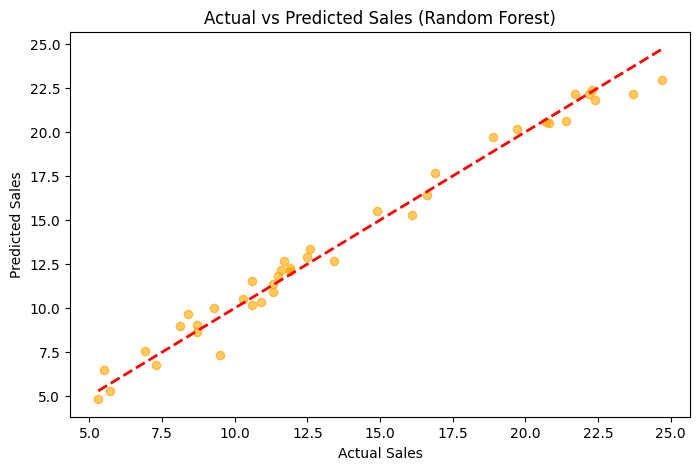

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_predictions, color='orange', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

### Feature Importance — Random Forest

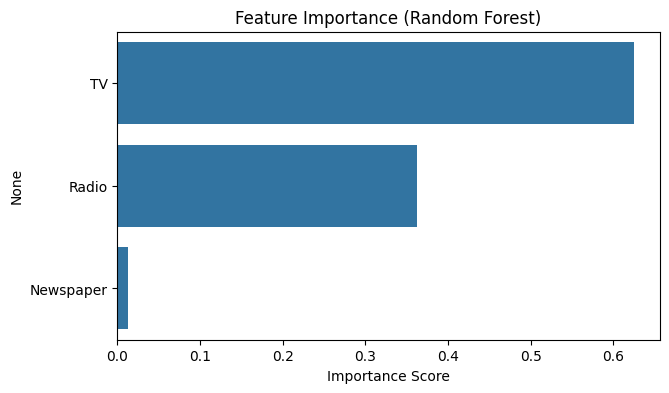


Average Sales: 14.02 thousand units


In [16]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

print("\nAverage Sales:", round(df['Sales'].mean(), 2), "thousand units")

## Conclusion

TV advertising showed the strongest correlation with sales, followed by Radio, while Newspaper had the least impact. The Random Forest model outperformed Linear Regression with a higher R2 score and lower error metrics. The project successfully demonstrates how advertising spend data can be used to predict future sales using machine learning.